<hr style="
    border: 0;
    height: 2px;
    background-color:#003366;
    width:80%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">


<div style="text-align:center;">

<h style="color:#003366; font-size:48px; margin-bottom:10px;">
  🐍  <b>Sprint 11</b>  📊
</h>



  <h2 style="color:#C9B037; font-size:42px; margin-top:0;">
    Data Visualization,
    Python & Power BI
  </h2>

</div>
<hr style="
    border: 0;
    height: 2px;
    background-color:#003366;
    width:80%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">

<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:65%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">


<div style="text-align:center;">

<h2 style="color:#003366;">Description :</h2>

<p style="color:#777777;">
This practice integrates the use of Python with the Pandas, Matplotlib, Seaborn, or Plotly libraries, as well as its integration with Power BI.<br>
You will work through the entire process from connecting to MySQL, creating advanced visualizations in Python,<br>
and finally incorporating these visualizations into a dynamic report in Power BI
</p>



<p style="color:#CC4444; font-style:italic;">
For this Sprint, all documentation and code will be written entirely in English to ensure consistency and technical clarity.
</p>

</div>

<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:65%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">


In [4]:
# Import all libraries needed for the sprint:


# Data manipulation and numerical computation

import numpy as np
import pandas as pd
from datetime import datetime, date, timedelta
import random
import string
import os

# Visualization

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


# To connect MySql 

import mysql.connector
from mysql.connector import Error


In [5]:
# Connection with MySQL and creation of the database dictionary

try:
    connection = mysql.connector.connect(host="localhost",
                                         database="Transfer_Analytics",
                                         user="root",
                                         password="ContraseñaMySql890@")

    if connection.is_connected():
        print("connection complete:", connection)

        cursor = connection.cursor()
        print("Cursor ready to work")

        cursor.execute("SHOW TABLES")
        tables = cursor.fetchall()

        dics_tables = {}

        for table in tables:
            name_tab = table[0]
            df = pd.read_sql(f"SELECT * FROM {name_tab}", connection)
            dics_tables[name_tab] = df
        
        print("Dict created!!!")

except Error:
    print("Error to connect MySQL!!!")

connection complete: <mysql.connector.connection_cext.CMySQLConnection object at 0x00000200E31AD400>
Cursor ready to work


C:\Users\eirad\AppData\Local\Temp\ipykernel_23152\1569175920.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(f"SELECT * FROM {name_tab}", connection)


Dict created!!!


In [6]:
# Checking NaN

print("Number of NaN for each table:")
print("-" * 30)

for table_name, df in dics_tables.items():
    total_nulls = df.isna().sum().sum()
    print(f"{table_name}: {total_nulls}")
    
print("-" * 30)

Number of NaN for each table:
------------------------------
american_users: 0
cards_analysis: 0
companies: 0
credit_cards: 0
european_users: 0
products: 0
transactions: 0
transactions_details: 0
users: 0
------------------------------


In [7]:
# Deleting unnecessary tables

del dics_tables["american_users"]
del dics_tables["european_users"]

dics_tables.keys()

dict_keys(['cards_analysis', 'companies', 'credit_cards', 'products', 'transactions', 'transactions_details', 'users'])

In [8]:
# Cheking info tables

for table in dics_tables:
    print(dics_tables[table].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   card_id       5000 non-null   object
 1   status_cards  5000 non-null   object
dtypes: object(2)
memory usage: 78.3+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            100 non-null    object
 1   company_name  100 non-null    object
 2   phone         100 non-null    object
 3   email         100 non-null    object
 4   country       100 non-null    object
 5   website       100 non-null    object
dtypes: object(6)
memory usage: 4.8+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0  

<div style="text-align:center;">


<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">

<h3><span style="color:#003366">News columns:<br></span></h3>
<p style="color:#777777;">
Creating new columns in the users products and transactions tables, where I will calculate ranges based on quintiles.
</p>

</p>

</div>

In [9]:
# Calculate "age" 

def calculo_edat(raw):

    today = datetime.now()

    age = today.year - raw.year

    if (today.month,raw.month) < (today.day,raw.month):
        age -= 1

    return age


dics_tables["users"]["age"] = dics_tables["users"]["birth_date"].apply(calculo_edat)

In [10]:
# Calculate age_range

def age_range(age):

    if age <= 31:
        return "20-31"
    elif age <= 41:
        return "32-41"
    elif age <= 53:
        return "42-53"
    elif age <= 65:
        return "54-65"
    else:
        return "66-76"
    
dics_tables["users"]["age_range"] = dics_tables["users"]["age"].apply(age_range)

In [11]:
# Creating "full_name"

dics_tables["users"]["full_name"] = dics_tables["users"]["name"] + " " + dics_tables["users"]["surname"]

In [12]:
# Calculate "price_range"

def price_range(price):

    if price <= 40.29:
        return "1.low"
    elif price <= 78.28:
        return "2.low-medium"
    elif price <= 127.23:
        return "3.medium"
    elif price <= 167.23:
        return "4.medium-high"
    else:
        return "5.high"
    
dics_tables["products"]["price_range"] = dics_tables["products"]["price_$"].apply(price_range)

In [13]:
# Calculate "month_name"

dics_tables["transactions"]["month_name"] = dics_tables["transactions"]["timestamp"].dt.month_name()

# Calculate "year"

dics_tables["transactions"]["year"] = dics_tables["transactions"]["timestamp"].dt.year

<div style="text-align:center;">
    

<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">

</div>


<div style="text-align:center;">
    

<h2 style="color:#C9B037;">Level 2</h2>


<h3><span style="color:#003366">Exercise 1: <br></span></h3>
<p style="color:#777777;">
1. Represent the correlation of some variables and interpret the results according to your data.
</p>

</div>



In [14]:
# Correlation of some variables, using "users" and "transactions" tables

df_h = pd.merge(dics_tables["users"],dics_tables["transactions"], how="left" ,left_on="id",right_on="user_id",suffixes=("_user","_trans"))

df_h = df_h[["user_id","full_name","amount","age","age_range"]].groupby("user_id").agg(full_name = ("full_name","first") , total_amount = ("amount","sum"), avg_amount = ( "amount","mean"), age = ("age","min"),age_range = ("age_range","first")).round(2)

df_h = df_h.sort_values("age_range",ascending=True)

In [ ]:
# Visualaze correlation between total amount and age users

graphic_h = px.scatter(df_h, x = "total_amount" , y = "age" ,size = "avg_amount" , color = "age_range", hover_name = "full_name", trendline="ols",
                       color_discrete_sequence = ["#999999", "#94D2BD", "#0A9396", "#005F73", "#002B36"], title= "Users : Correlation between total amount and age ")

graphic_h.update_layout( width=1400, height=800)

graphic_h.update_layout(title_font_color="#1d3e58",
                        title={"text": "Users : Correlation between total amount and age ","x": 0.5,"xanchor": "center",
                             "yanchor": "top","font": {"size": 32,"color": "#1d3e58" }},
                             
                             legend=dict(font=dict(size=17, color="#1d3e58"),
                                                  title_font=dict(size=22, color="#1d3e58")))

graphic_h.show()

<div style="text-align:center;">
<h3><span style="color:#C9B037;">Insights :<br></span></h3>
<font color="#777777">
This scatter plot examines the relationship between total spending and user age across five demographic groups.<br>
The data shows that while most users spend under $15,000, high-value outliers exist across all age ranges.<br>
The relatively flat regression lines suggest that age is not a primary driver of total spending,<br>
indicating consistent purchasing behavior throughout the user life cycle.
</font>
</div>

<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">

<div style="text-align:center;">

<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">

<h3><span style="color:#003366">Exercise 2: <br></span></h3>
<p style="color:#777777;">
2. Implement a Jointplot to explore the relationship between two variables and interpret the results according to your data.
</p>

</div>

In [15]:
# Jointplot , Correlation between two variables more some extra details , using "transactions" and "users" tables 

''' Utilizing Plotly Express instead of Seaborn's jointplot to leverage interactive marginal distributions and built-in OLS trendline analysis '''

df_i = dics_tables["transactions"][dics_tables["transactions"]["declined"] == 0]

df_i = pd.merge( df_i , dics_tables["users"] , left_on= "user_id" , right_on= "id" , suffixes= ("_trans","_user"))

df_i = df_i.groupby("city").agg(avg_trans = ("amount","mean"), max_trans = ("amount","max") ,tot_trans = ("amount","sum"), count_users = ("user_id","count")).round(2)


In [ ]:
# Visualize the correlation between average and total transaction amounts by city

graphic_i = px.scatter(df_i.reset_index(), x="avg_trans", y="tot_trans", marginal_x="histogram", marginal_y="histogram",trendline="ols",
                     size = "count_users" , size_max=30, hover_name="city", hover_data={"avg_trans": True, "tot_trans": True}, color="max_trans")

# Adjust figure size
graphic_i.update_layout( width=1200, height=800)

# Configure title
graphic_i.update_layout(title={"text": "Total vs Average Transaction Amount", "x": 0.5,"xanchor": "center",
                             "yanchor": "top","font": {"size": 32,"color": "#FFFFFF" }})

# Apply colors
graphic_i.update_layout(coloraxis_colorscale="Ice")

graphic_i.update_layout(paper_bgcolor="#1a1a1a", plot_bgcolor="#1a1a1a",
                      font_color="#FFFFFF",legend_title_font_color="#FFFFFF",legend_font_color="#FFFFFF")

graphic_i.update_xaxes(color= "#FFFFFF", gridcolor="#333")
graphic_i.update_yaxes(color="#FFFFFF", gridcolor="#333")

# Customize hist and trendline
graphic_i.update_traces(marker_color="#1d3e58", marker_line_color="#cccccc", marker_line_width=1.5, selector=dict(type="histogram"))
graphic_i.update_traces(line=dict( color= "#cecac3", width=3), selector=dict(mode="lines"))

# Configure colorbar
graphic_i.update_layout(coloraxis_colorbar=dict(orientation="h",y=-0.3,x=0.5,xanchor="center",title="max_trans"))

graphic_i.show()


<div style="text-align:center;">
<h3><span style="color:#C9B037;">Insights :<br></span></h3>
<font color="#777777">
This Joint Plot provides a sophisticated geographical analysis, where each data point represents a specific city.<br>
By examining cities like Genoa, which boasts 1,420 users and nearly $400k in total transactions, we can see a clear <br>
relationship between local user density and overall revenue. The marginal histograms reveal that most cities maintain <br>
a highly consistent average transaction value around $260, regardless of their size.<br>
The slight positive regression trend suggests that cities with higher individual spending habits also drive significantly higher total market value.<br>
This visualization is crucial for identifying high-performing urban hubs and understanding how city-level user counts directly impact the company's regional financial success.
</font>
</div>


<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">

<div style="text-align:center;">
    

<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">

</div>


<div style="text-align:center;">
    

<h2 style="color:#C9B037;">Level 3</h2>


<h3><span style="color:#003366">Exercise 1: <br></span></h3>
<p style="color:#777777;">
Transfer all Level 1 visualizations to Power BI using Python scripts.<br><br><br>
<span style="color:#C94F4F;">
Remember:<br>
When loading your dataframes into Power BI, make sure to include an identifier column or a combination of columns that guarantees the uniqueness of each record.<br>
By default, Power BI removes duplicates, and you could lose information.”
</span>
</p>

</div>


<div style="text-align:center;">

<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">

</div>

<div style="text-align:center;">

<h3><span style="color:#003366">Development:<br></span></h3>

<p style="color:#777777;">
I created a single script that includes all the steps I previously performed and generated unique identifier columns for all Level‑1 dataframes,<br>
so I can import them already prepared and ready to use at once.

</p>
</div>

In [ ]:
''' 
# Import all libraries needed:

# Data manipulation and numerical computation

import numpy as np
import pandas as pd
from datetime import datetime, date, timedelta
import random
import string

# To connect MySql 

import mysql.connector
from mysql.connector import Error

# Connection with MySQL and creation of the database dictionary

try:
    connection = mysql.connector.connect(host="localhost",
                                         database="Transfer_Analytics",
                                         user="root",
                                         password="ContraseñaMySql890@")

    if connection.is_connected():
        print("connection complete:", connection)

        cursor = connection.cursor()
        print("Cursor ready to work")

        cursor.execute("SHOW TABLES")
        tables = cursor.fetchall()

        dics_tables = {}

        for table in tables:
            name_tab = table[0]
            df = pd.read_sql(f"SELECT * FROM {name_tab}", connection)
            dics_tables[name_tab] = df
        
        print("Dict created!!!")

except Error:
        print("Error to connect MySQL!!!")


# Calculate "age"

def calculate_age(raw):

    today = datetime.now()

    age = today.year - raw.year

    if (today.month,raw.month) < (today.day,raw.month):
        age -= 1

    return age


dics_tables["users"]["age"] = dics_tables["users"]["birth_date"].apply(calculate_age)

# Calculate age_range

def age_range(age):

    if age <= 31:
        return "20-31"
    elif age <= 41:
        return "32-41"
    elif age <= 53:
        return "42-53"
    elif age <= 65:
        return "54-65"
    else:
        return "66-76"
    
dics_tables["users"]["age_range"] = dics_tables["users"]["age"].apply(age_range)

# Creating "full_name"

dics_tables["users"]["full_name"] = dics_tables["users"]["name"] + " " + dics_tables["users"]["surname"]

# Calculate "price_range"

def price_range(price):

    if price <= 40.29:
        return "1.low"
    elif price <= 78.28:
        return "2.low-medium"
    elif price <= 127.23:
        return "3.medium"
    elif price <= 167.23:
        return "4.medium-high"
    else:
        return "5.high"
    
dics_tables["products"]["price_range"] = dics_tables["products"]["price_$"].apply(price_range)

# Calculate "month_name"

dics_tables["transactions"]["month_name"] = dics_tables["transactions"]["timestamp"].dt.month_name()

# Calculate "year"

dics_tables["transactions"]["year"] = dics_tables["transactions"]["timestamp"].dt.year


# Generate unique identifier columns for all Level‑1 dataframes

# df_a 

df_a = dics_tables["products"][["price_$"]]

df_a = df_a.reset_index().rename(columns={"index": "id"})


#df_b

df_b = dics_tables["users"][["user_region"]]

df_b = df_b.reset_index().rename(columns={"index": "id"})


# df_c

df_c = pd.merge( dics_tables["transactions"], dics_tables["users"] , left_on= "user_id" , right_on= "id",suffixes= ("_trans","_user") )

df_c = df_c[df_c["declined"] == 0]

df_c = df_c[["user_id","full_name","amount"]].groupby(["user_id","full_name"]).mean("amount").round(0)

df_c = df_c.sort_values("amount", ascending= False)

df_c = df_c.reset_index().rename(columns={"index": "user_id"})



# df_d

df_d = pd.crosstab(dics_tables["users"]["age_range"],dics_tables["users"]["country"]).transpose()

df_d = df_d.loc[df_d.sum(axis=1).sort_values(ascending=False).index]

df_d = df_d.reset_index().rename(columns={"index": "country"})



# df_e


prod = dics_tables["products"][["id","product_name","price_$","price_range"]]

declined_false = dics_tables["transactions"][dics_tables["transactions"]["declined"] == 0]  # Transaction No declined

details = dics_tables["transactions_details"][dics_tables["transactions_details"]["transaction_id"].isin(declined_false["id"])]

details = details.groupby("product_id").count()

df_e = pd.merge(prod, details,left_on= "id",right_on="product_id", how="inner")

df_e = df_e.rename(columns={"transaction_id" : "quantity sold"})

df_e["unique_id"] = [''.join(random.choices(string.ascii_uppercase + string.digits, k=4))for _ in range(len(df_e))]


# df_f

df_f = pd.merge(dics_tables["transactions"],dics_tables["users"],left_on= "user_id", right_on="id")

df_f = df_f[df_f["declined"] == 0]

df_f = df_f.sort_values("timestamp",ascending= True)

df_f["unique_id"] = [''.join(random.choices(string.ascii_uppercase + string.digits, k=4))for _ in range(len(df_f))]


#df_g

prod = dics_tables["products"]

declined_false = dics_tables["transactions"][dics_tables["transactions"]["declined"] == 0]  # Transaction No declined!

details = dics_tables["transactions_details"][dics_tables["transactions_details"]["transaction_id"].isin(declined_false["id"])]

details_trans = pd.merge(details,dics_tables["transactions"],left_on="transaction_id",right_on="id")

details_trans = details_trans.groupby("product_id").agg( quantity_sold = ("product_id","count"), total_sales = ("amount","sum") )

df_g = pd.merge(prod, details_trans,left_on= "id",right_on="product_id", how="inner")

df_g = df_g.sort_values("price_range",ascending=True)

df_g["unique_id"] = [''.join(random.choices(string.ascii_uppercase + string.digits, k=4))for _ in range(len(df_g))]

order_price = ["1.low", "2.low-medium", "3.medium", "4.medium-high", "5.high"]



# Lineplot ,Sales Trends in the last 3 Years , using "transactions" table


df_extra = dics_tables["transactions"]

df_extra = df_extra[df_extra["declined"] == 0 ]

df_extra = df_extra[df_extra["year"] >= 2022]

month_order = ["January", "February", "March", "April", "May", "June","July", "August", "September", "October", "November", "December"]

df_extra["month_name"] = pd.Categorical(df_extra["month_name"], categories=month_order, ordered=True)

df_extra = df_extra[["year", "amount", "month_name"]].groupby(["year","month_name"]).sum("amount") 

df_extra = df_extra.sort_values(["year","month_name"],ascending= True)

df_extra = df_extra.reset_index()

df_extra["unique_id"] = [''.join(random.choices(string.ascii_uppercase + string.digits, k=4))for _ in range(len(df_extra))]

'''

<div style="text-align:center;">

<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">

</div>

<div style="text-align:center;">

<h2 style="color:#C9B037;"> BOXPLOT - "Price Distribution" </h2>

<h3>
    <span style="color:#003366">Script on Power BI:<br></span>
</h3>

</div>

<!-- Código alineado a la izquierda -->
<div style="text-align:left; color:#777777; font-family:monospace; margin-left:20%;">

import pandas as pd<br>
import matplotlib.pyplot as plt<br><br>

df_a = dataset[["price_$"]]<br><br>

plt.style.use('bmh')<br><br>

graphic_a = df_a.plot.box(title="Price Distribution", color="darkblue", medianprops=dict(color="purple"))<br><br>

plt.xticks([])<br>
plt.ylabel("Price_$")<br><br>

graphic_a.set_title("Price Distribution", fontsize=20, color="#1d3e58")<br>
graphic_a.yaxis.label.set_color("#2f2f2f")<br><br>

plt.show()<br>

</div>





<div style="text-align:center;">

<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">

</div>

<div style="text-align:center;">

<h2 style="color:#C9B037;"> PIE - "User Distribution by Region" </h2>

<h3>
    <span style="color:#003366">Script on Power BI:<br></span>
</h3>

</div>

<!-- Código alineado a la izquierda -->
<div style="text-align:left; color:#777777; font-family:monospace; margin-left:20%;">

import pandas as pd<br>
import matplotlib.pyplot as plt<br><br>

df_b = dataset["user_region"]<br><br>

plt.style.use('bmh')<br><br>

graphic_b = df_b.value_counts().plot.pie(autopct='%1.1f%%', ylabel="",<br>
&nbsp;&nbsp;&nbsp;&nbsp;colors=["#8D65D1", "#76C7C5"], textprops={'color': "#1d3e58"})<br><br>

graphic_b.set_title("User Distribution by Region", fontsize=20, color="#1d3e58")<br><br>

plt.show()<br>

</div>


<div style="text-align:center;">

<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">

</div>

<div style="text-align:center;">

<h2 style="color:#C9B037;"> BARH - "Top 10 Client by Avg Amount" </h2>

<h3>
    <span style="color:#003366">Script on Power BI:<br></span>
</h3>

</div>

<!-- Código alineado a la izquierda -->
<div style="text-align:left; color:#777777; font-family:monospace; margin-left:20%;">

import pandas as pd<br>
import matplotlib.pyplot as plt<br><br>

df_c = dataset.groupby(["user_id","full_name"])["amount"].mean()<br>
&nbsp;&nbsp;&nbsp;&nbsp;.sort_values(ascending=False).head(10)<br><br>

graphic_c = df_c.plot.barh(figsize=(10,6), color="green",<br>
&nbsp;&nbsp;&nbsp;&nbsp;ylabel="ID and full name", xlabel="avg amount",<br>
&nbsp;&nbsp;&nbsp;&nbsp;title="Top 10 Client by Avg Amount")<br><br>

graphic_c.set_title("Top 10 Client by Avg Amount", fontsize=20, color="#1d3e58")<br><br>

graphic_c.yaxis.label.set_color("#1d3e58")<br>
graphic_c.xaxis.label.set_color("#1d3e58")<br><br>

graphic_c.tick_params(axis='both', colors="#1d3e58")<br><br>

plt.show()<br>

</div>


<div style="text-align:center;">

<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">

</div>

<div style="text-align:center;">

<h2 style="color:#C9B037;"> BARH - "Users count by country and age_range" </h2>

<h3>
    <span style="color:#003366">Script on Power BI:<br></span>
</h3>

</div>

<!-- Código alineado a la izquierda -->
<div style="text-align:left; color:#777777; font-family:monospace; margin-left:20%;">

import pandas as pd<br>
import matplotlib.pyplot as plt<br><br>

df_d = dataset.set_index("country")[["20-31", "32-41", "42-53", "54-65", "66-76"]]<br><br>

df_d = df_d.loc[df_d.sum(axis=1).sort_values(ascending=False).index]<br><br>

plt.style.use('bmh')<br><br>

graphic_d = df_d.plot.barh(figsize=(14,4), stacked=True,<br>
&nbsp;&nbsp;&nbsp;&nbsp;color=("#999999", "#94D2BD", "#0A9396", "#005F73", "#002B36"),<br>
&nbsp;&nbsp;&nbsp;&nbsp;ylabel="", xlabel="users_count",<br>
&nbsp;&nbsp;&nbsp;&nbsp;title="Users count by country and age_range")<br><br>

graphic_d.set_title("Users count by country and age_range", fontsize=20, color="#1d3e58")<br><br>

graphic_d.yaxis.label.set_color("#1d3e58")<br>
graphic_d.xaxis.label.set_color("#1d3e58")<br><br>

graphic_d.tick_params(axis='both', colors="#1d3e58")<br><br>

graphic_d.legend(title="Age range", bbox_to_anchor=(1.02,1))<br><br>

plt.show()<br>

</div>



<div style="text-align:center;">

<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">

</div>

<div style="text-align:center;">

<h2 style="color:#C9B037;"> SCATTER - "Correlation between price and quantity sold" </h2>

<h3>
    <span style="color:#003366">Script on Power BI:<br></span>
</h3>
<p style="color:#C94F4F; font-weight:bold;">
Plotly library doesn’t work with Power BI, so I need to create a similar graphic using Seaborn!
</p>


</div>


<div style="text-align:left; color:#777777; font-family:monospace; margin-left:20%;">
import pandas as pd  
import matplotlib.pyplot as plt  
import seaborn as sns

df_e = dataset[["price_$", "quantity sold", "product_name", "price_range"]]<br><br>

plt.style.use('bmh')<br><br>

plt.figure(figsize=(10,6))<br><br>

graphic_e = sns.regplot(data=df_e, x="price_$", y="quantity sold",<br>
&nbsp;&nbsp;&nbsp;&nbsp;line_kws={"color": "#1d3e58"},<br>
&nbsp;&nbsp;&nbsp;&nbsp;scatter_kws={"s": df_e["price_$"] * 4, "alpha": 0.6})<br><br>

plt.xlabel("Price ($)")<br>
plt.ylabel("Quantity Sold")<br><br>

graphic_e.set_title("Correlation between price and quantity sold", fontsize=20, color="#1d3e58")<br><br>

graphic_e.yaxis.label.set_color("#1d3e58")<br>
graphic_e.xaxis.label.set_color("#1d3e58")<br><br>

graphic_e.tick_params(axis='both', colors="#1d3e58")<br><br>

plt.show()<br>

</div>


<div style="text-align:center;">

<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">

</div>

<div style="text-align:center;">

<h2 style="color:#C9B037;"> VIOLIN PLOT - "Transaction amount by month and user region" </h2>

<h3>
    <span style="color:#003366">Script on Power BI:<br></span>
</h3>

<p style="color:#CC0000; font-weight:bold;">

</p>

</div>

<div style="text-align:left; color:#777777; font-family:monospace; margin-left:20%;">

import pandas as pd  
import matplotlib.pyplot as plt  
import seaborn as sns

df_f = dataset[["month_name","amount","user_region"]]<br><br>

plt.style.use('bmh')<br><br>

plt.figure(figsize=(18, 8))<br>
plt.title("Transaction amount by month and user region", fontsize=20)<br>
plt.xlabel(" ")<br><br>

graphic_f = sns.violinplot(df_f, x="month_name", y="amount", hue="user_region",<br>
&nbsp;&nbsp;&nbsp;&nbsp;split="user_region", palette="mako")<br><br>

graphic_f.set_title("Transaction amount by month and user region", fontsize=20, color="#1d3e58")<br><br>

graphic_f.yaxis.label.set_color("#1d3e58")<br>
graphic_f.xaxis.label.set_color("#1d3e58")<br><br>

graphic_f.tick_params(axis='both', colors="#1d3e58")<br><br>

plt.show()<br>

</div>


<div style="text-align:center;">

<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">

</div>

<div style="text-align:center;">

<h2 style="color:#C9B037;"> PAIRPLOT - "Focus on Product Sales" </h2>

<h3>
    <span style="color:#003366">Script on Power BI:<br></span>
</h3>

</div>


<div style="text-align:left; color:#777777; font-family:monospace; margin-left:20%;">

import pandas as pd<br>
import matplotlib.pyplot as plt<br>
import seaborn as sns<br><br>

df_g = dataset[["price_$","price_range","quantity_sold","total_sales","weight"]]<br><br>

plt.style.use('bmh')<br><br>

graphic_g = sns.pairplot(df_g, hue="price_range", diag_kind="kde", corner=False,<br>
&nbsp;&nbsp;&nbsp;&nbsp;palette="mako", hue_order=["1.low", "2.low-medium", "3.medium", "4.medium-high", "5.high"])<br><br>

graphic_g.fig.suptitle("Focus on Product Sales", fontsize=24, y=1.02, color="#1d3e58")<br><br>

for ax in graphic_g.axes.flatten():<br>
&nbsp;&nbsp;&nbsp;&nbsp;if ax is not None:<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;ax.xaxis.label.set_color("#1d3e58")<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;ax.yaxis.label.set_color("#1d3e58")<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;ax.tick_params(axis='both', colors="#1d3e58")<br><br>

plt.show()<br>

</div>


<div style="text-align:center;">

<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">

</div>

<div style="text-align:center;">

<h2 style="color:#C9B037;">Extra</h2>

<h3><span style="color:#003366">Exercise Date</span></h3>

<p style="color:#777777;">
I would like to analyze a variable of type <strong>date</strong>.
</p>

</div>

In [16]:
# Lineplot ,Sales Trends in the last 5 Years , using "transactions" table

df_extra = dics_tables["transactions"]

df_extra = df_extra[df_extra["declined"] == 0 ]

df_extra = df_extra[df_extra["year"] >= 2022]

month_order = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]

df_extra["month_name"] = pd.Categorical(df_extra["month_name"], categories=month_order, ordered=True)

df_extra = df_extra[["year", "amount", "month_name"]].groupby(["year","month_name"]).sum("amount") 

df_extra = df_extra.sort_values(["year","month_name"],ascending= True)

df_extra = df_extra.reset_index()


C:\Users\eirad\AppData\Local\Temp\ipykernel_23152\3371381734.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_extra = df_extra[["year", "amount", "month_name"]].groupby(["year","month_name"]).sum("amount")


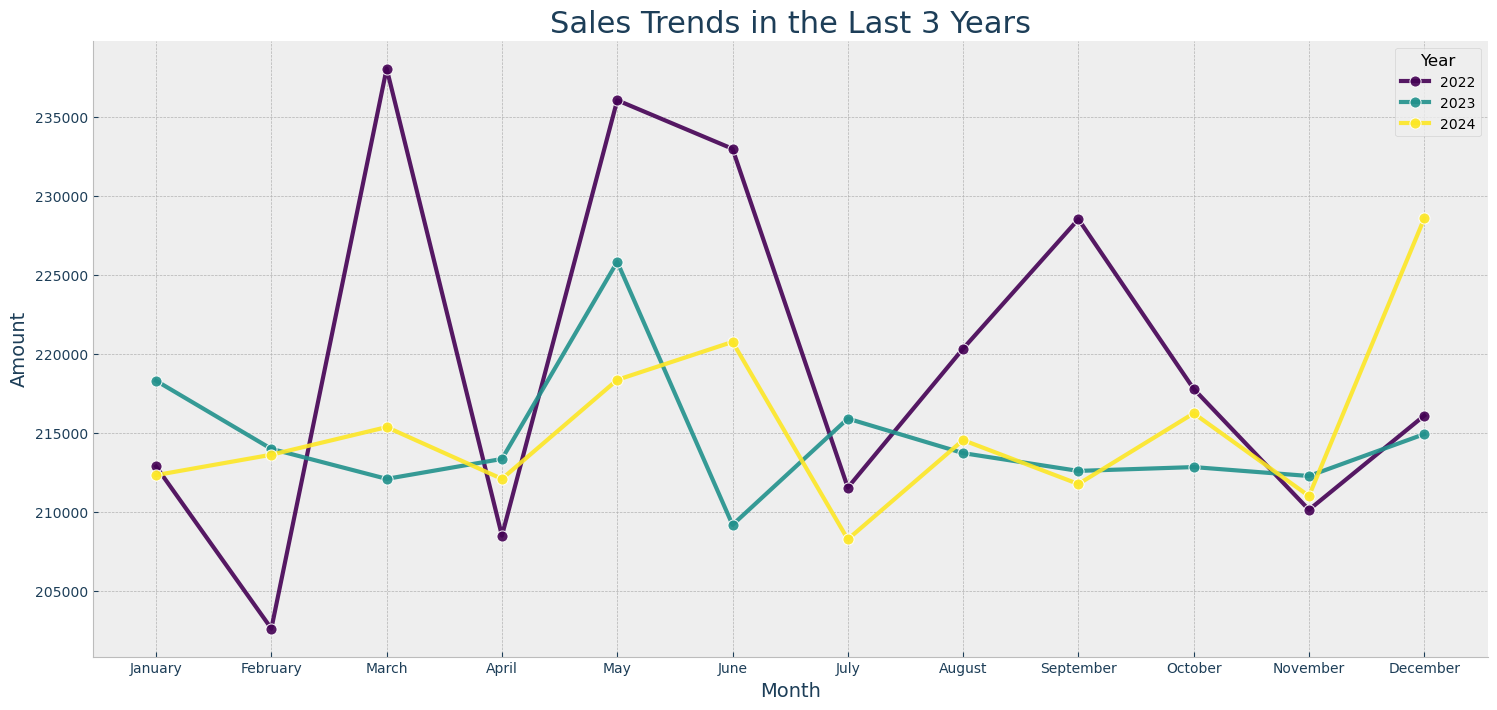

In [17]:
# Visualize sales trends in the last 3 years

plt.style.use('bmh')
plt.figure(figsize=(18, 8))

graphic_t = sns.lineplot(x="month_name", y="amount",hue="year",data=df_extra,marker="o",
                         linewidth=3,markersize=8, alpha=0.9 ,palette="viridis")

graphic_t.set_title("Sales Trends in the Last 3 Years",fontsize=22,color="#1d3e58")


# Set colors and size
graphic_t.set_xlabel("Month", fontsize=14, color="#1d3e58")
graphic_t.set_ylabel("Amount", fontsize=14, color="#1d3e58")

graphic_t.yaxis.label.set_color("#1d3e58")
graphic_t.xaxis.label.set_color("#1d3e58")
graphic_t.tick_params(axis='both', colors="#1d3e58")


plt.legend(title="Year", title_fontsize=12, fontsize=10)

sns.despine()

plt.show()

<div style="text-align:center;">
<h3><span style="color:#D4AF37">Insights :<br></span></h3>
<font color="#777777">
This chart tracks sales performance over a three-year period, highlighting significant volatility in 2022 with major peaks in March and May. <br>
While 2023 shows more stabilized growth, 2024 concludes with a sharp upward trend in December, indicating a strong year-end performance.<br> 
Overall, the data suggests evolving seasonal dynamics and a positive growth trajectory moving into the most recent months.
</font>
</div>

<div style="text-align:center;">

<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">



<div style="text-align:center;">
<hr style="border: 0;height: 2px;background-color:#777777;width:60%;margin:25px auto;box-shadow: 0 2px 6px rgba(0,0,0,0.25);">
</div>
<div style="text-align:center;">
<h2 style="color:#C9B037;"> LINEPLOT – "Sales Trends in the Last 3 Years" </h2>
<h3><span style="color:#003366">Script on Power BI:<br></span></h3>
</div>
<div style="text-align:left; color:#777777; font-family:monospace; margin-left:20%;">
import pandas as pd<br> 
import matplotlib.pyplot as plt<br> 
import seaborn as sns<br><br>

df_extra = dataset[["year","month_name","amount"]]<br><br>

month_order = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]<br><br>
df_extra["month_name"] = pd.Categorical(df_extra["month_name"],categories=month_order, ordered=True)<br><br>

plt.style.use('bmh')<br> plt.figure(figsize=(18, 8))<br><br>

graphic_t = sns.lineplot(x="month_name", y="amount", hue="year", data=df_extra, marker="o",linewidth=3, markersize=8, alpha=0.9, palette="viridis")<br><br>

graphic_t.set_title("Sales Trends in the Last 3 Years", fontsize=22, color="#1d3e58")<br><br>

graphic_t.set_xlabel("Month", fontsize=14, color="#1d3e58")<br> graphic_t.set_ylabel("Amount", fontsize=14, color="#1d3e58")<br><br>

graphic_t.yaxis.label.set_color("#1d3e58")<br> graphic_t.xaxis.label.set_color("#1d3e58")<br> graphic_t.tick_params(axis='both', colors="#1d3e58")<br><br>

plt.legend(title="Year", title_fontsize=12, fontsize=10)<br><br>
sns.despine()<br><br>
plt.show()<br>
</div>
<div style="text-align:center;">
<hr style="border: 0;height: 2px;background-color:#777777;width:60%;margin:25px auto;box-shadow: 0 2px 6px rgba(0,0,0,0.25);">
</div>

<hr style="
    border: 0;
    height: 2px;
    background-color:#003366;
    width:80%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">


<div style="text-align:center;">
<hr style="
    border: 0;
    height: 2px;
    background-color:#003366;
    width:80%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">


<div style="text-align:center;">